# Medidas de correlação

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau, shapiro

In [7]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [10]:
numericas = df.select_dtypes(include='number')
numericas.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


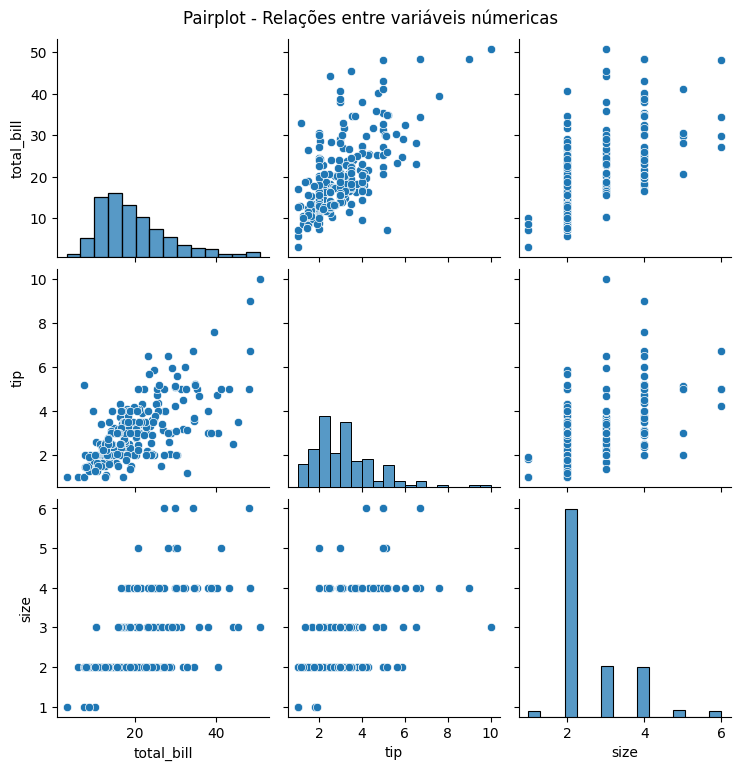

In [12]:
sns.pairplot(numericas)
plt.suptitle('Pairplot - Relações entre variáveis númericas', y=1.02)
plt.show()

## Teste de normalidade

In [15]:
for col in numericas.columns:
    stat, p = shapiro(numericas[col])
    print(f"{col}: stat={stat:.4f}, p={p:.4f}")

total_bill: stat=0.9197, p=0.0000
tip: stat=0.8978, p=0.0000
size: stat=0.7120, p=0.0000


Nenhuma variável segue a distruibuição normal, já que nenhum valor de p é maior que 0.05

## Correlação de pearson

In [17]:
pearson_corr = df['total_bill'].corr(df['tip'], method='pearson')
print(f"Correlação entre `total_bill` e `tip` é {pearson_corr:.4f}")

Correlação entre `total_bill` e `tip` é 0.6757


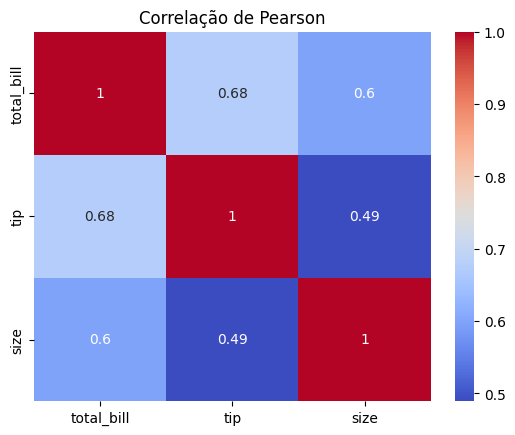

In [19]:
corr_pearson = numericas.corr(method='pearson')
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.title("Correlação de Pearson")
plt.show()

## Correlação de Spearman

In [21]:
spearman_corr = df['total_bill'].corr(df['tip'], method='spearman')
print(f"Correlação entre `total_bill` e `tip` é {spearman_corr:.4f}")

Correlação entre `total_bill` e `tip` é 0.6790


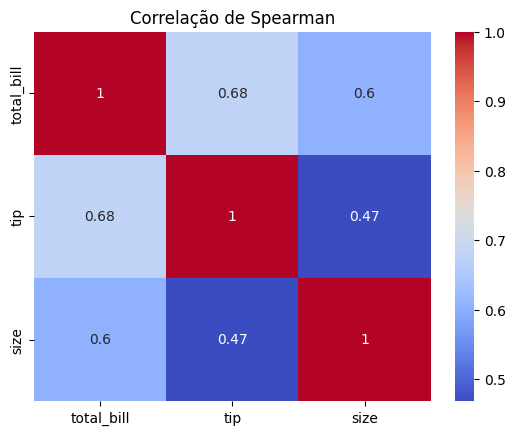

In [22]:
spearman_corr = numericas.corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm")
plt.title("Correlação de Spearman")
plt.show()

## Correlação de Kendall

In [23]:
kendall_corr = df['total_bill'].corr(df['tip'], method='kendall')
print(f"Correlação entre `total_bill` e `tip` é {kendall_corr:.4f}")

Correlação entre `total_bill` e `tip` é 0.5172


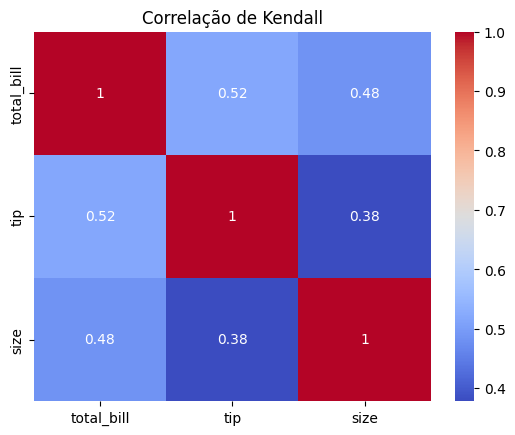

In [25]:
kendall_corr = numericas.corr(method='kendall')
sns.heatmap(kendall_corr, annot=True, cmap="coolwarm")
plt.title("Correlação de Kendall")
plt.show()

## Teste de hipótese para correlação entre total_bill e tip

In [35]:
r, p = pearsonr(df['total_bill'], df['tip'])
print(f"Pearson: {r=:.4f}, {p=:.4f}")

r, p = spearmanr(df['total_bill'], df['tip'])
print(f"Spearman: {r=:.4f}, {p=:.4f}")

r, p = kendalltau(df['total_bill'], df['tip'])
print(f"Kendall: {r=:.4f}, {p=:.4f}")

Pearson: r=0.6757, p=0.0000
Spearman: r=0.6790, p=0.0000
Kendall: r=0.5172, p=0.0000


> Quando tempos `p < 0.05`, podemos dizer que temos uma correlação significativa